# Scene graph Visualization

In [1]:
import os
from pathlib import Path

import json
import random
import re
import textwrap
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Markdown, display
from matplotlib.backends.backend_agg import FigureCanvasAgg
from matplotlib.patches import FancyArrowPatch
from PIL import Image

from swift.model import get_model_processor, get_processor
from swift.template import get_template
from swift.infer_engine import InferRequest, RequestConfig, TransformersEngine, VllmEngine

In [2]:
ROOT = Path("/data/homes/makarov_vd/workspace/SceneGraphVLM")

GPU_ID = "4"
CHECKPOINT_DIR = ROOT / "sft/Qwen3.5/work_dirs/pvsg_maxinfo_Qwen3.5-0.8B/v5-20260409-135802/checkpoint-8844"
TEST_JSONL = ROOT / "datasets/data_playground/PVSG_json/pvsg_psfr_gt_prompt/test_clean.jsonl"
IMAGES_BASE = ""  # optional prefix when jsonl "images" paths are relative
SEED = None       # int for reproducible row index

DRAW_MAX_WIDTH = 1200  # set 0 to disable resizing in the draw step

INFER_BACKEND = "vllm"  # "vllm" | "transformers"
TEMPERATURE = 0.0
MAX_NEW_TOKENS = 2048
MAX_MODEL_LEN = 8192
GPU_MEMORY_UTILIZATION = 0.35
TENSOR_PARALLEL_SIZE = 1
TORCH_DTYPE = "bfloat16"
TEMPLATE_TYPE = ""  # empty: auto
ENABLE_THINKING = False

os.environ["CUDA_VISIBLE_DEVICES"] = GPU_ID
os.environ.setdefault("VLLM_ENABLE_V1_MULTIPROCESSING", "0")

print("ROOT =", ROOT)
print("CHECKPOINT_DIR =", CHECKPOINT_DIR)
print("TEST_JSONL =", TEST_JSONL)
print("CUDA_VISIBLE_DEVICES =", os.environ.get("CUDA_VISIBLE_DEVICES"))


ROOT = /data/homes/makarov_vd/workspace/SceneGraphVLM
CHECKPOINT_DIR = /data/homes/makarov_vd/workspace/SceneGraphVLM/sft/Qwen3.5/work_dirs/pvsg_maxinfo_Qwen3.5-0.8B/v5-20260409-135802/checkpoint-8844
TEST_JSONL = /data/homes/makarov_vd/workspace/SceneGraphVLM/datasets/data_playground/PVSG_json/pvsg_psfr_gt_prompt/test_clean.jsonl
CUDA_VISIBLE_DEVICES = 4


In [ ]:
_REL_PAIR_LINE_RE = re.compile(
    r"^\s*(\d+)\s*,\s*(\[[^\]]*\])\s*,\s*(\[[^\]]*\])\s*,\s*(\[[^\]]*\])\s*,\s*(\d+)\s*$"
)


def _bracket_inner(br: str) -> str:
    br = br.strip()
    if len(br) >= 2 and br[0] == "[" and br[-1] == "]":
        return br[1:-1].strip()
    return br


def _rel_pair_pred(att_b: str, spat_b: str, cont_b: str) -> str:
    chunks = []
    for inner in (_bracket_inner(att_b), _bracket_inner(spat_b), _bracket_inner(cont_b)):
        if not inner:
            continue
        parts = [p.strip() for p in inner.split(",") if p.strip()]
        if parts:
            chunks.append("/".join(parts))
    return "|".join(chunks) if chunks else "rel"


_OBJ_HEADER_RE = re.compile(r"^(?:obj)?\[(\d+)\]\{id,name,x1,y1,x2,y2\}", re.IGNORECASE)
_REL_TRIPLE_HEADER_RE = re.compile(r"^(?:rel)?\[(\d+)\]\{subj,pred,obj\}", re.IGNORECASE)


def _scan_obj_rel_headers(lines: List[str]) -> Tuple[Optional[int], Optional[int], Optional[str]]:
    obj_i = rel_i = None
    rel_mode: Optional[str] = None
    for i, line in enumerate(lines):
        s = line.strip()
        if _OBJ_HEADER_RE.match(s):
            obj_i = i
        if _REL_TRIPLE_HEADER_RE.match(s):
            rel_i, rel_mode = i, "triple"
        if s.startswith("rel_pairs[") and "{subj,attention,spatial,contacting,obj}" in s:
            rel_i, rel_mode = i, "pairs"
    return obj_i, rel_i, rel_mode


def _try_repair_missing_obj_header_block(text: str) -> Optional[str]:
    lines = [ln.strip() for ln in text.splitlines() if ln.strip()]
    obj_i, rel_i, rel_mode = _scan_obj_rel_headers(lines)
    if rel_i is None or rel_mode is None or obj_i is not None:
        return None
    raw_obj = lines[:rel_i]
    rest = lines[rel_i:]
    fixed: List[str] = []
    next_id = 1
    for raw in raw_obj:
        parts = [p.strip() for p in raw.split(",")]
        if len(parts) == 6:
            try:
                oid = int(parts[0])
                int(parts[2])
                int(parts[3])
                int(parts[4])
                int(parts[5])
            except ValueError:
                continue
            fixed.append(raw)
            next_id = max(next_id, oid + 1)
        elif len(parts) == 5:
            name, a, b, c, d = parts
            try:
                int(a)
                int(b)
                int(c)
                int(d)
            except ValueError:
                continue
            if name.isdigit():
                continue
            fixed.append(f"{next_id},{name},{a},{b},{c},{d}")
            next_id += 1
    if not fixed:
        return None
    k = len(fixed)
    header = f"obj[{k}]{{id,name,x1,y1,x2,y2}}:"
    return "\n".join([header, *fixed, *rest])


def repair_scene_graph_text_if_needed(text: str) -> str:
    r = _try_repair_missing_obj_header_block(text)
    return r if r is not None else text


def parse_scene_graph_output(text: str) -> dict:
    lines = [ln.strip() for ln in text.splitlines() if ln.strip()]
    oi, ri, rm = _scan_obj_rel_headers(lines)
    if oi is None and ri is not None and rm is not None:
        rep = _try_repair_missing_obj_header_block(text)
        if rep:
            lines = [ln.strip() for ln in rep.splitlines() if ln.strip()]
            oi, ri, rm = _scan_obj_rel_headers(lines)
    if oi is None or ri is None or rm is None:
        raise ValueError("missing obj/rel headers")
    objects = []
    for raw in lines[oi + 1 : ri]:
        s = raw.strip()
        if not s:
            continue
        parts = [p.strip() for p in s.split(",")]
        if len(parts) != 6:
            continue
        try:
            oid = int(parts[0])
            x1, y1, x2, y2 = int(parts[2]), int(parts[3]), int(parts[4]), int(parts[5])
        except ValueError:
            continue
        x1, x2 = sorted((x1, x2))
        y1, y2 = sorted((y1, y2))
        objects.append({"id": oid, "label": parts[1], "bbox": [x1, y1, x2, y2]})
    relations = []
    if rm == "triple":
        for raw in lines[ri + 1 :]:
            s = raw.strip()
            if not s:
                continue
            parts = [p.strip() for p in s.split(",")]
            if len(parts) != 3:
                continue
            try:
                relations.append({"sub": int(parts[0]), "pred": parts[1], "obj": int(parts[2])})
            except ValueError:
                pass
    else:
        for raw in lines[ri + 1 :]:
            m = _REL_PAIR_LINE_RE.match(raw.strip())
            if not m:
                continue
            pred = _rel_pair_pred(m.group(2), m.group(3), m.group(4))
            relations.append({"sub": int(m.group(1)), "obj": int(m.group(5)), "pred": pred})
    return {"objects": objects, "relations": relations}


def draw_scene_graph(
    image,
    answer_text: str,
    max_width: Optional[int] = None,
    title: Optional[str] = None,
    title_wrap_long: bool = False,
) -> Image.Image:
    img = Image.open(image).convert("RGB") if isinstance(image, (str, bytes, bytearray)) else image.convert("RGB")
    ow, oh = img.size
    scale = 1.0
    if max_width is not None and ow > max_width:
        scale = max_width / float(ow)
        img = img.resize((int(ow * scale), int(oh * scale)), Image.LANCZOS)
    dw, dh = img.size
    try:
        sg = parse_scene_graph_output(answer_text)
    except ValueError:
        sg = {"objects": [], "relations": []}
    dpi = 100
    fw, fh = dw / dpi, dh / dpi
    if title:
        if title_wrap_long:
            mcl = max(20, int(dw / 8))
            nln = max(1, (len(title) + mcl - 1) // mcl)
            th = 0.4 + (nln - 1) * 0.15
            tot = fh + th
            fig = plt.figure(figsize=(fw, tot), dpi=dpi, facecolor="white")
            tax = fig.add_axes([0, fh / tot, 1, th / tot], facecolor="white")
            fs = 12 if len(title) <= 100 else 10 if len(title) <= 150 else 8
            tax.text(0.5, 0.5, "\n".join(textwrap.wrap(title, width=mcl)), fontsize=fs, fontweight="bold", ha="center", va="center")
            tax.axis("off")
            ax = fig.add_axes([0, 0, 1, fh / tot], facecolor="white")
        else:
            th, tot = 0.5, fh + 0.5
            fig = plt.figure(figsize=(fw, tot), dpi=dpi, facecolor="white")
            tax = fig.add_axes([0, fh / tot, 1, th / tot], facecolor="white")
            tax.text(0.5, 0.5, title, fontsize=14, fontweight="bold", ha="center", va="center")
            tax.axis("off")
            ax = fig.add_axes([0, 0, 1, fh / tot], facecolor="white")
    else:
        fig = plt.figure(figsize=(fw, fh), dpi=dpi, facecolor="white")
        ax = fig.add_axes([0, 0, 1, 1], facecolor="white")
    ax.imshow(img)
    ax.axis("off")
    n = len(sg["objects"])
    if n > 0:
        pal = plt.cm.tab20(np.linspace(0, 1, max(20, n)))
        ctr = {}
        for i, ob in enumerate(sg["objects"]):
            x1, y1, x2, y2 = ob["bbox"]
            x1s, y1s = int(round(x1 * scale)), int(round(y1 * scale))
            x2s, y2s = int(round(x2 * scale)), int(round(y2 * scale))
            w, h = max(1, x2s - x1s), max(1, y2s - y1s)
            c = pal[i % len(pal)]
            ax.add_patch(patches.Rectangle((x1s, y1s), w, h, linewidth=2, edgecolor=c, facecolor="none"))
            fs = 7 if h >= 14 else 6 if h >= 9 else 5
            ax.text(x1s + 2, y1s + 2, f"{ob['id']}: {ob['label']}", fontsize=fs, color="white", va="top", bbox=dict(facecolor=c, alpha=0.75, pad=0.6))
            ctr[ob["id"]] = ((x1s + x2s) / 2, (y1s + y2s) / 2)
        for rel in sg["relations"]:
            su, ou = rel["sub"], rel["obj"]
            if su in ctr and ou in ctr:
                sx, sy = ctr[su]
                ox, oy = ctr[ou]
                ax.add_patch(FancyArrowPatch((sx, sy), (ox, oy), arrowstyle="->", mutation_scale=14, color="yellow", linewidth=2, alpha=0.9))
                ax.text((sx + ox) / 2, (sy + oy) / 2, rel["pred"], fontsize=6, color="yellow", bbox=dict(facecolor="black", alpha=0.55, boxstyle="round,pad=0.2"))
    canvas = FigureCanvasAgg(fig)
    canvas.draw()
    buf = np.asarray(canvas.buffer_rgba())
    plt.close(fig)
    return Image.fromarray(buf).convert("RGB")


# === Swift inference helpers ===

_THINK_END = "</redacted_thinking>"
_SG_OBJ_HDR = re.compile(r"^\s*(?:obj)?\[\d+\]\{id,name", re.MULTILINE)
_SG_REL_HDR = re.compile(r"^\s*(?:rel)?\[\d+\]\{subj,pred,obj\}", re.MULTILINE)
_SG_RP_HDR = re.compile(r"^\s*rel_pairs\[\d+\]\{subj,attention", re.MULTILINE)


def strip_thinking_suffix(text: str) -> str:
    s = text.strip()
    while _THINK_END in s:
        i = s.find(_THINK_END)
        pre, suf = s[:i], s[i + len(_THINK_END) :].lstrip()
        if _SG_OBJ_HDR.search(pre) or _SG_REL_HDR.search(pre) or _SG_RP_HDR.search(pre):
            s = (pre + "\n" + suf).strip() if suf else pre.strip()
            break
        if not suf:
            return pre.strip() if pre.strip() else ""
        s = suf
    return s


def truncate_first_answer_block(text: str) -> str:
    s = text.strip()
    j = s.find("</answer>")
    if j != -1:
        return s[: j + len("</answer>")].strip()
    if "<answer>" in s:
        return s.rstrip() + "\n</answer>\n"
    return s


def finalize_vl_prediction(raw: str) -> str:
    return truncate_first_answer_block(strip_thinking_suffix(raw))


def read_jsonl(path: Path) -> List[Dict[str, Any]]:
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def get_user_text(sample: Dict[str, Any]) -> str:
    for m in sample.get("messages", []):
        if m.get("role") == "user":
            return (m.get("content") or "").strip()
    raise ValueError("no user message")


def get_assistant_text(sample: Dict[str, Any]) -> str:
    for m in sample.get("messages", []):
        if m.get("role") == "assistant":
            return (m.get("content") or "").strip()
    raise ValueError("no assistant message")


def resolve_image_path(sample: Dict[str, Any], base: Optional[str]) -> str:
    imgs = sample.get("images") or []
    if not imgs:
        raise ValueError("no images")
    p = imgs[0]
    if os.path.isabs(p):
        return p
    return p if not base else os.path.join(base, p)


def parse_torch_dtype(name: str) -> torch.dtype:
    d = getattr(torch, name, None)
    if not isinstance(d, torch.dtype):
        raise ValueError(name)
    return d


def build_engine(model_path: str, backend: str, **kw):
    tt = kw["template_type"]
    if backend == "vllm":
        proc = get_processor(model_path, torch_dtype=kw["dtype"], trust_remote_code=True)
        tmpl = get_template(proc, template_type=tt, enable_thinking=kw["enable_thinking"], response_prefix=None)
        return VllmEngine(
            model_path,
            template=tmpl,
            max_model_len=kw["max_model_len"],
            gpu_memory_utilization=kw["gpu_mem"],
            tensor_parallel_size=kw["tp"],
            limit_mm_per_prompt={"image": 1},
        )
    if backend == "transformers":
        model, proc = get_model_processor(model_path, torch_dtype=kw["dtype"], trust_remote_code=True)
        tmpl = get_template(proc, template_type=tt, enable_thinking=kw["enable_thinking"], response_prefix=None)
        return TransformersEngine(model, template=tmpl, max_batch_size=1)
    raise ValueError(backend)


_images_base = (IMAGES_BASE or "").strip() or None
_tt = (TEMPLATE_TYPE or "").strip() or None
_dtype = parse_torch_dtype(TORCH_DTYPE.strip())
_draw_max = DRAW_MAX_WIDTH if isinstance(DRAW_MAX_WIDTH, int) and DRAW_MAX_WIDTH > 0 else None

engine = build_engine(
    str(CHECKPOINT_DIR),
    INFER_BACKEND,
    max_model_len=MAX_MODEL_LEN,
    gpu_mem=GPU_MEMORY_UTILIZATION,
    tp=TENSOR_PARALLEL_SIZE,
    template_type=_tt or None,
    enable_thinking=ENABLE_THINKING,
    dtype=_dtype,
)

req_cfg = RequestConfig(max_tokens=MAX_NEW_TOKENS, temperature=TEMPERATURE, stop=["</answer>"])

print("Ready:", type(engine).__name__)


`torch_dtype` is deprecated! Use `dtype` instead!
[INFO:swift] Successfully registered `/data/homes/makarov_vd/.conda/envs/swift_qwen_3_5_sft/lib/python3.11/site-packages/swift/dataset/data/dataset_info.json`.


[INFO:swift] Successfully loaded /data/homes/makarov_vd/workspace/SceneGraphVLM/sft/Qwen3.5/work_dirs/pvsg_maxinfo_Qwen3.5-0.8B/v5-20260409-135802/checkpoint-8844/args.json.
[INFO:swift] Setting model_type: qwen3_5
[WARNING:swift] Please install the package: `pip install "decord" -U`.
[INFO:swift] model_kwargs: {'device_map': 'cuda:0', 'dtype': torch.bfloat16}
[INFO:swift] Setting max_ratio: 200. You can adjust this hyperparameter through the environment variable: `MAX_RATIO`.
[INFO:swift] Setting frame_factor: 2. You can adjust this hyperparameter through the environment variable: `FRAME_FACTOR`.
[INFO:swift] Setting fps: 2.0. You can adjust this hyperparameter through the environment variable: `FPS`.
[INFO:swift] Setting fps_min_frames: 4. You can adjust this hyperparameter through the environment variable: `FPS_MIN_FRAMES`.
[INFO:swift] Setting fps_max_frames: 768. You can adjust this hyperparameter through the environment variable: `FPS_MAX_FRAMES`.
[INFO:swift] Setting image_max_t

WARNING 04-09 16:21:05 [arg_utils.py:1352] The global random seed is set to 0. Since VLLM_ENABLE_V1_MULTIPROCESSING is set to False, this may affect the random state of the Python process that launched vLLM.


The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.
Unrecognized keys in `rope_parameters` for 'rope_type'='default': {'mrope_interleaved', 'mrope_section'}
Unrecognized keys in `rope_parameters` for 'rope_type'='default': {'mrope_interleaved', 'mrope_section'}


INFO 04-09 16:21:05 [model.py:533] Resolved architecture: Qwen3_5ForConditionalGeneration
INFO 04-09 16:21:05 [model.py:1582] Using max model len 8192
INFO 04-09 16:21:05 [scheduler.py:231] Chunked prefill is enabled with max_num_batched_tokens=2048.
INFO 04-09 16:21:07 [config.py:212] Setting attention block size to 544 tokens to ensure that attention page size is >= mamba page size.
INFO 04-09 16:21:07 [config.py:243] Padding mamba page size by 2.64% to ensure that mamba page size and attention page size are exactly equal.
INFO 04-09 16:21:07 [vllm.py:754] Asynchronous scheduling is enabled.
INFO 04-09 16:21:10 [core.py:103] Initializing a V1 LLM engine (v0.18.0) with config: model='/data/homes/makarov_vd/workspace/SceneGraphVLM/sft/Qwen3.5/work_dirs/pvsg_maxinfo_Qwen3.5-0.8B/v5-20260409-135802/checkpoint-8844', speculative_config=None, tokenizer='/data/homes/makarov_vd/workspace/SceneGraphVLM/sft/Qwen3.5/work_dirs/pvsg_maxinfo_Qwen3.5-0.8B/v5-20260409-135802/checkpoint-8844', skip_t

<frozen importlib._bootstrap_external>:1241: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
<frozen importlib._bootstrap_external>:1241: FutureWarning: The cuda.nvrtc module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.nvrtc module instead.


Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]


INFO 04-09 16:21:13 [default_loader.py:384] Loading weights took 0.65 seconds
INFO 04-09 16:21:14 [gpu_model_runner.py:4566] Model loading took 1.72 GiB memory and 1.152501 seconds
INFO 04-09 16:21:14 [gpu_model_runner.py:5488] Encoder cache will be initialized with a budget of 16384 tokens, and profiled with 1 image items of the maximum feature size.
INFO 04-09 16:21:19 [backends.py:988] Using cache directory: /data/homes/makarov_vd/.cache/vllm/torch_compile_cache/3e070f2f35/rank_0_0/backbone for vLLM's torch.compile
INFO 04-09 16:21:19 [backends.py:1048] Dynamo bytecode transform time: 3.63 s
INFO 04-09 16:21:19 [backends.py:371] Cache the graph of compile range (1, 2048) for later use
INFO 04-09 16:21:22 [backends.py:387] Compiling a graph for compile range (1, 2048) takes 2.56 s
INFO 04-09 16:21:23 [decorators.py:627] saved AOT compiled function to /data/homes/makarov_vd/.cache/vllm/torch_compile_cache/torch_aot_compile/9c158f60e6f13b3b48f1cbd4d7b7b782f6ec6523030f51413f81b9d05bff03

Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|██████████| 51/51 [00:01<00:00, 27.28it/s]
Capturing CUDA graphs (decode, FULL): 100%|██████████| 35/35 [00:00<00:00, 39.42it/s]


INFO 04-09 16:21:28 [gpu_model_runner.py:5746] Graph capturing finished in 4 secs, took 0.35 GiB
INFO 04-09 16:21:28 [gpu_worker.py:617] CUDA graph pool memory: 0.35 GiB (actual), 0.31 GiB (estimated), difference: 0.04 GiB (11.7%).
INFO 04-09 16:21:28 [core.py:281] init engine (profile, create kv cache, warmup model) took 14.58 seconds
Ready: VllmEngine


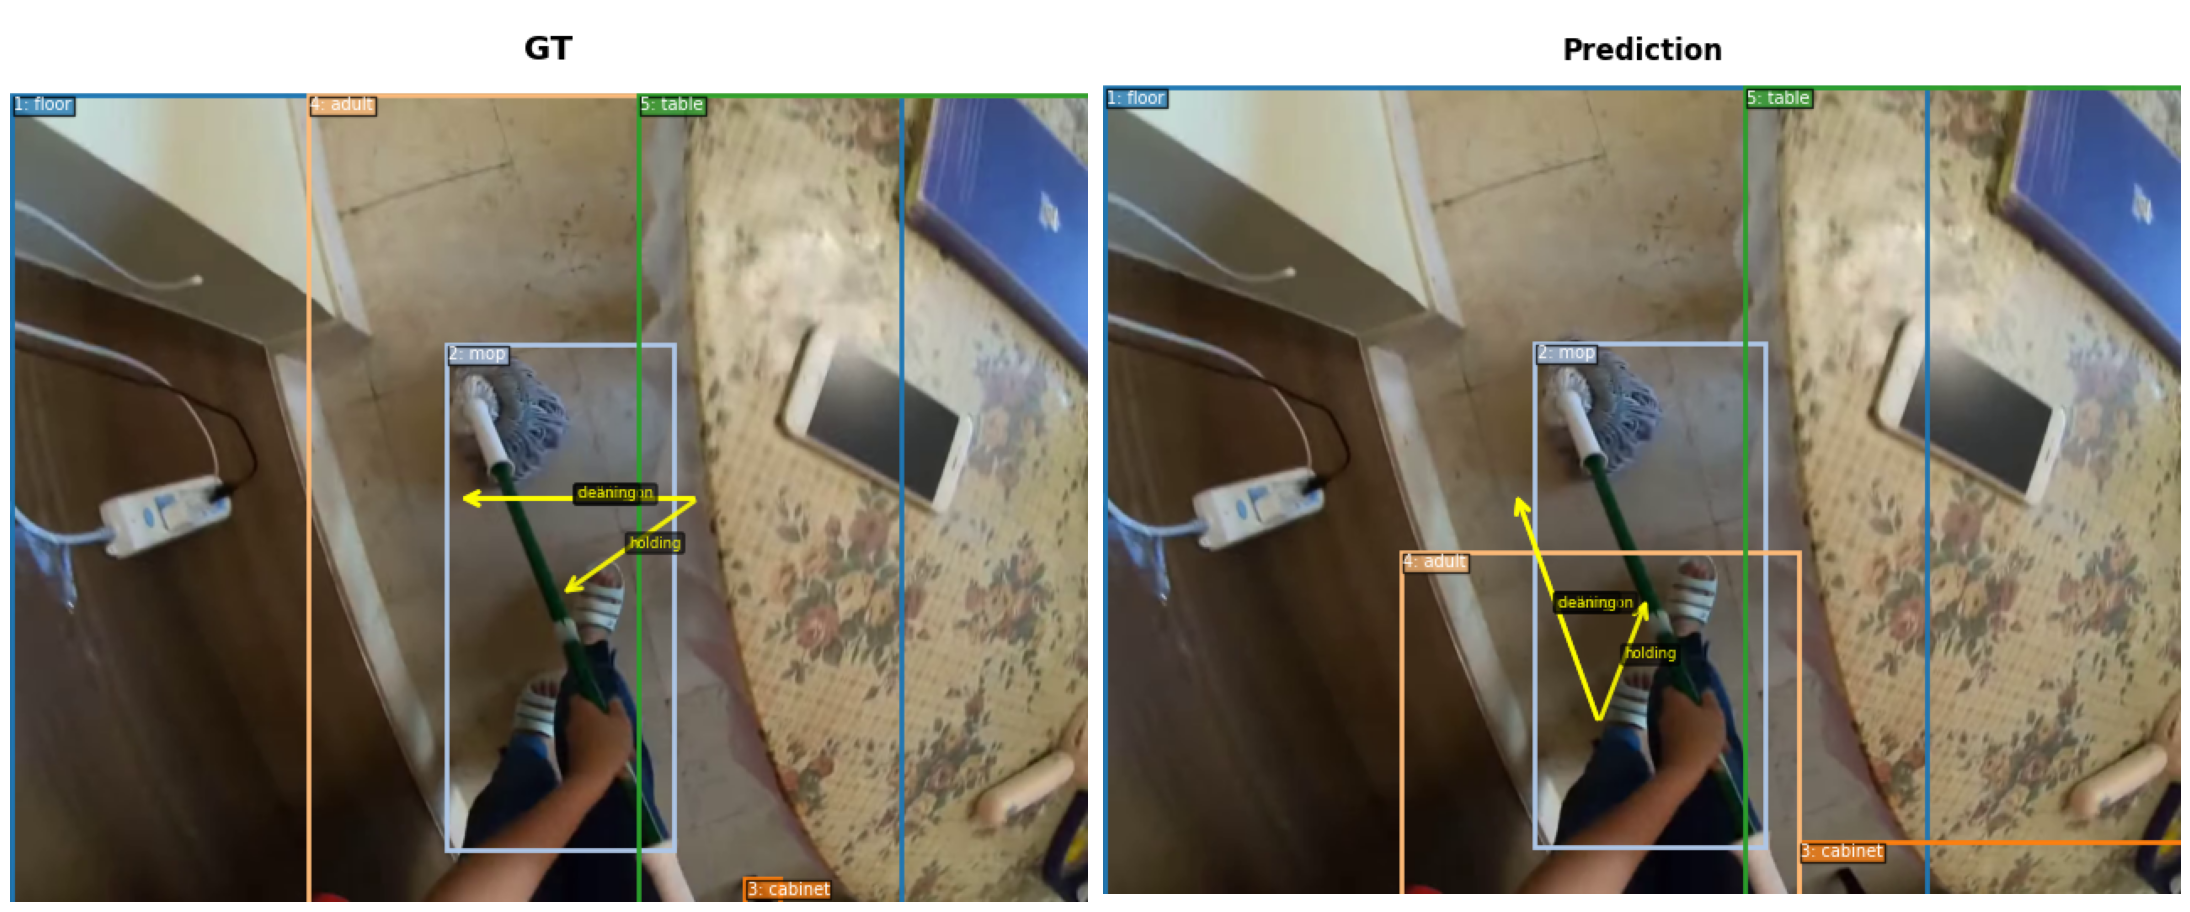

row_index = 2334
image = /data/homes/makarov_vd/workspace/SceneGraphVLM/datasets/frames/PVSG_frames/test_images/ego4d/frames/43b0205a-4e3c-46a7-9d1c-c04ead730180/0317.png


### User

<image>
Generate a structured scene graph for an image of size (640 x 480) using the following text format.

Output Format:

<answer>
obj[N]{id,name,x1,y1,x2,y2}:
  id,name,x1,y1,x2,y2
  ...
rel[M]{subj,pred,obj}:
  subj,pred,obj
  ...

</answer>
Guidelines:
- Objects:
  - Use integer IDs starting from 1 in the id field (e.g., 1, 2, 3).
  - The name must be the object category name (e.g., person, umbrella).
  - Provide the bounding box [x1, y1, x2, y2] in integer pixel format.
  - Include all visible objects, even if they have no relationships.

- Relationships:
  - Represent interactions using integer object IDs in subj and obj.
  - pred is the relationship type (string), such as in-front-of, attached-to, beside.
  - Omit relationships for objects that do not participate in any interaction.

Example output:
<answer>
obj[7]{id,name,x1,y1,x2,y2}:
  1,person,281,272,524,438
  2,umbrella,273,123,640,434
  3,house,0,88,262,426
  4,window-other,163,262,195,294
  5,tree-merged,0,0,640,440
  

### Ground truth

<answer>
      obj[5]{id,name,x1,y1,x2,y2}:
        1,floor,0,0,528,480
        2,mop,258,148,393,448
        3,cabinet,435,465,456,480
        4,adult,176,0,640,480
        5,table,372,0,640,480
      rel[3]{subj,pred,obj}:
        4,holding,2
        4,walking-on,1
        4,cleaning,1
</answer>


### Prediction

<think>

</think>

<answer>
      obj[5]{id,name,x1,y1,x2,y2}:
        1,floor,0,0,488,480
        2,mop,255,152,392,452
        3,cabinet,412,448,640,480
        4,adult,176,276,412,480
        5,table,380,0,640,480
      rel[3]{subj,pred,obj}:
        4,holding,2
        4,walking-on,1
        4,cleaning,1
</answer>


In [5]:
rows = read_jsonl(TEST_JSONL)
if not rows:
    raise RuntimeError("empty JSONL")

rng = random.Random(SEED)
idx = rng.randrange(len(rows))
sample = rows[idx]
prompt = get_user_text(sample)
gt_text = get_assistant_text(sample)
img_path = resolve_image_path(sample, _images_base)
if not os.path.isfile(img_path):
    raise FileNotFoundError(img_path)

infer_request = InferRequest(messages=[{"role": "user", "content": prompt}], images=[img_path])
response = engine.infer([infer_request], req_cfg)[0]
pred_text = finalize_vl_prediction(response.choices[0].message.content or "")
pred_text = repair_scene_graph_text_if_needed(pred_text)

gt_img = draw_scene_graph(img_path, gt_text, max_width=_draw_max, title="GT", title_wrap_long=False)
pr_img = draw_scene_graph(img_path, pred_text, max_width=_draw_max, title="Prediction", title_wrap_long=True)

fig, axes = plt.subplots(1, 2, figsize=(22, 10))
axes[0].imshow(gt_img)
axes[0].axis("off")
axes[1].imshow(pr_img)
axes[1].axis("off")
plt.tight_layout()
plt.show()

print("row_index =", idx)
print("image =", img_path)
display(Markdown("### User"))
print(prompt)
display(Markdown("### Ground truth"))
print(gt_text)
display(Markdown("### Prediction"))
print(pred_text)
